In [1]:
#import statements
import os
os.chdir("..")
from pathlib import Path
from typing import List, Dict, Optional, Union
from t2Interp.T2I import T2IModel
from t2Interp.intervention import EncoderAttentionIntervention, ScalingAttentionIntervention #, InterventionRunner
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from datasets import load_dataset
from tqdm import tqdm
from diffusers import AutoPipelineForText2Image, LCMScheduler

/home/ubuntu/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## K-Steering Class

In [2]:
#Here's the classifier 
class K_Steering:
    def __init__(self, input_dim, num_classes=6, hidden_dim=256, lr=1e-3, device='cuda'):
        """
        Parameters:
          - input_dim: dimensionality of your raw activations.
          - num_classes: number of tone classes to classify.
          - hidden_dim: size of the hidden layer in the MLP.
          - lr: learning rate for training the classifier.
          - device: 'cuda' or 'cpu'.
        """
        self.device = device
        self.num_classes = num_classes
        
        # Define a multi-class MLP classifier
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)  # outputs logits for each tone class
        ).to(device)
        
        self.optimizer = optim.Adam(self.classifier.parameters(), lr=lr)
        self.loss_fn = nn.CrossEntropyLoss()
        
        # Store class names for reference
        self.class_names = None
        

    def fit(self, activations_dict, epochs=30, batch_size=32, class_weights=None, val_split=0.2):
        """
        Train the multiclass classifier on raw activations.

        Parameters:
          - activations_dict: Dictionary mapping class names to NumPy arrays of activations.
          - epochs: number of training epochs.
          - batch_size: training batch size.
          - class_weights: Optional tensor of weights for each class to handle imbalance.
          - val_split: Fraction of data to use for validation (default: 0.2)
        """
        self.class_names = list(activations_dict.keys())
        assert len(self.class_names) == self.num_classes, f"Expected {self.num_classes} classes, got {len(self.class_names)}"
        
        # Prepare data and split train/val
        X_list = []
        y_list = []
        
        for i, class_name in enumerate(self.class_names):
            X_class = torch.tensor(activations_dict[class_name], dtype=torch.float32, device=self.device)
            y_class = torch.full((X_class.size(0),), i, dtype=torch.long, device=self.device)
            X_list.append(X_class)
            y_list.append(y_class)
        
        X = torch.cat(X_list, dim=0)
        y = torch.cat(y_list, dim=0)
        
        # Split train/val
        n_total = X.size(0)
        n_val = int(n_total * val_split)
        indices = torch.randperm(n_total)
        train_idx, val_idx = indices[n_val:], indices[:n_val]
        
        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]
        
        train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
        val_dataset = torch.utils.data.TensorDataset(X_val, y_val)
        
        train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")
        
        # Set class weights for loss function if provided
        if class_weights is not None:
            self.loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(self.device))
        else:
            self.loss_fn = nn.CrossEntropyLoss()
        
        # Train the classifier
        for epoch in range(epochs):
            self.classifier.train()
            epoch_loss = 0.0
            train_correct = 0
            train_total = 0
            
            for batch_X, batch_y in train_loader:
                self.optimizer.zero_grad()
                logits = self.classifier(batch_X)  # shape: (batch, num_classes)
                loss = self.loss_fn(logits, batch_y)
                loss.backward()
                self.optimizer.step()
                
                epoch_loss += loss.item()
                
                # Calculate accuracy
                _, predicted = torch.max(logits.data, 1)
                train_total += batch_y.size(0)
                train_correct += (predicted == batch_y).sum().item()
            
            # Validate
            self.classifier.eval()
            val_correct = 0
            val_total = 0
            
            with torch.no_grad():
                for batch_X, batch_y in val_loader:
                    logits = self.classifier(batch_X)
                    _, predicted = torch.max(logits.data, 1)
                    val_total += batch_y.size(0)
                    val_correct += (predicted == batch_y).sum().item()
            
            train_acc = 100 * train_correct / train_total
            val_acc = 100 * val_correct / val_total
            avg_loss = epoch_loss / len(train_loader)
            
            print(f"Epoch {epoch}: Loss={avg_loss:.4f}, Train={train_acc:.1f}%, Val={val_acc:.1f}%")
            
        # Evaluate per-class on validation set
        self.classifier.eval()
        class_accuracies = {}
        
        with torch.no_grad():
            for i, class_name in enumerate(self.class_names):
                # Get validation samples for this class
                class_mask = y_val == i
                if class_mask.sum() == 0:
                    continue
                
                X_class_val = X_val[class_mask]
                y_class_val = y_val[class_mask]
                
                logits = self.classifier(X_class_val)
                _, predicted = torch.max(logits.data, 1)
                accuracy = 100 * (predicted == y_class_val).sum().item() / y_class_val.size(0)
                class_accuracies[class_name] = accuracy
                print(f"Val accuracy for {class_name}: {accuracy:.2f}%")

    def steer_attributes(self, activation, target=None, avoid=None, alpha=0.1, steps=1, decay_rate=0.95):
        """
        Steer the given activation toward target tones and away from tones to avoid.
        
        Parameters:
        - activation: a NumPy array of shape (D,) or (N, D).
        - target_tones: list of tone names to steer toward.
        - avoid_tones: list of tone names to steer away from.
        - alpha: scaling factor for the update.
        - steps: number of gradient descent steps to take.
        
        Returns:
        - The modified activation as a NumPy array.
        """
        
        # Get indices for target and avoid tones
        target_indices = [self.class_names.index(tone) for tone in target] if target else []
        avoid_indices = [self.class_names.index(tone) for tone in avoid] if avoid else []
        
        
        # Convert activation to a torch tensor
        X = torch.tensor(activation, dtype=torch.float32, device=self.device)
        
        current_alpha = alpha
        
        # Perform multiple steps of gradient descent
        for step in range(steps):
            if step > 0:
                current_alpha *= decay_rate
            # Need to create a new tensor that requires gradients for each step
            X = X.detach().requires_grad_(True)
            
            # Forward pass: compute classifier output (logits)
            self.classifier.eval()
            logits = self.classifier(X)  # shape: [N, num_classes]
            
            # Create custom loss function to maximize target tone scores and minimize avoid tone scores
            loss = 0
            
            if target_indices:
                target_logits = logits[:, target_indices]
                # Negative because we want to maximize these logits (gradient descent will minimize)
                loss = loss - target_logits.mean()
            
            if avoid_indices:
                avoid_logits = logits[:, avoid_indices]
                # Positive because we want to minimize these logits
                loss = loss + avoid_logits.mean()
            
            # If no target or avoid tones provided, do nothing
            if not target_indices and not avoid_indices:
                return activation
            
            # Compute gradients
            loss.backward()
            
            # Get the gradient with respect to the input activation
            grad = X.grad.data
            
            # Update the activation by moving in the loss gradient direction
            # Negative gradient because we're trying to minimize the loss

            X = X - current_alpha * grad
        
        # Convert back to NumPy
        X_new_np = X.detach().cpu().numpy()
        return X_new_np

    def steer_attributes_unsupervised(self, activation, alpha=0.1, steps=1, decay_rate=0.95):
        """
        Steer the given activation, calculate the mean of the activations of all classes and steer away of those above the mean and towards those away from the mean .
        
        Parameters:
        - activation: a NumPy array of shape (D,) or (N, D).
        - alpha: scaling factor for the update.
        - steps: number of gradient descent steps to take.
        
        Returns:
        - The modified activation as a NumPy array.
        """


        # Convert activation to a torch tensor
        X = torch.tensor(activation, dtype=torch.float32, device=self.device)
        
        current_alpha = alpha
        
        # Perform multiple steps of gradient descent
        for step in range(steps):
            if step > 0:
                current_alpha *= decay_rate
            # Need to create a new tensor that requires gradients for each step
            X = X.detach().requires_grad_(True)
            
            # Forward pass: compute classifier output (logits)
            self.classifier.eval()
            logits = self.classifier(X)  # shape: [N, num_classes]
            
            # Create custom loss function to maximize target tone scores and minimize avoid tone scores
            loss = 0
            mean_logits = torch.mean(logits, dim=1)

            target_indices = [i for i, logits in enumerate(logits) if logits[:,i].mean() < mean_logits]
            avoid_indices = [i for i, logits in enumerate(logits) if logits[:,i].mean() > mean_logits]
            
            if target_indices:
                target_logits = logits[:, target_indices]
                # Negative because we want to maximize these logits (gradient descent will minimize)
                loss = loss - target_logits.mean()
            
            if avoid_indices:
                avoid_logits = logits[:, avoid_indices]
                # Positive because we want to minimize these logits
                loss = loss + avoid_logits.mean()
            
            # If no target or avoid tones provided, do nothing
            if not target_indices and not avoid_indices:
                return activation
            
            # Compute gradients
            loss.backward()
            
            # Get the gradient with respect to the input activation
            grad = X.grad.data
            
            # Update the activation by moving in the loss gradient direction
            # Negative gradient because we're trying to minimize the loss

            X = X - current_alpha * grad
        
        # Convert back to NumPy
        X_new_np = X.detach().cpu().numpy()

        return X_new_np

## Utils for hook function

In [3]:
#These are the data loading functions
import torch, numpy as np, matplotlib.pyplot as plt, torchvision
from sklearn.decomposition import PCA
from PIL import Image

def visualize_image(x, title=None, figsize=(5,5)):
    # → torch.FloatTensor (CPU)
    if isinstance(x, Image.Image): x = np.array(x)
    x = torch.as_tensor(x).detach().cpu().float()
    #we should normalise rgb

    # Channels-last → channels-first if needed
    def ch_last_to_first(t):
        return t.permute(2,0,1) if t.ndim==3 and t.shape[-1] in (1,3) else t

    x = ch_last_to_first(x)
    cmap = None

    if x.ndim == 4:  # [B,C,H,W]
        grid = torchvision.utils.make_grid(x, nrow=2, normalize=True, padding=2)
        img = grid.permute(1,2,0).numpy()
        #we should normalise rgb
    elif x.ndim == 3:  # [C,H,W]
        C,H,W = x.shape
        if C == 1:
            img, cmap = x.squeeze(0).numpy(), 'gray'
        elif C == 3:
            img = x.permute(1,2,0).numpy()
        else:
            pcs = PCA(n_components=3).fit_transform(x.view(C,-1).T.numpy())
            pcs = (pcs - pcs.min())/(pcs.max()-pcs.min()+1e-8)
            img = pcs.reshape(H,W,3)
    elif x.ndim == 2:  # [H,W]
        img, cmap = x.numpy(), 'gray'
    else:

        raise ValueError(f"Unsupported shape: {tuple(x.shape)}")
    #normalise rgb
    img = img / 255.0
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap=cmap)
    plt.axis('off')
    if title: plt.title(title)
    plt.show()



def load_fairface_by_ethnicity_hf(
    hf_data,                           # e.g. load_dataset("HuggingFaceM4/FairFace", "0.25", split="train")
    categories: Optional[List[str]] = None,
    max_images: Optional[int] = None,  # per-category cap
    return_pil: bool = True,
    verbose: bool = True
) -> Dict[str, List[Union[str, Image.Image]]]:
    """
    Load FairFace (Hugging Face version) organized by racial/ethnic categories.
    Returns a dict: {category_key: [PIL.Image (or np.ndarray if return_pil=False), ...]}

    - Accepts both 'East Asian' and 'East_Asian' style names in `categories`.
    - `max_images` applies PER CATEGORY.
    - Works with standard datasets or streaming (IterableDataset).
    """

    # Discover label names (if available) to build defaults and map indices->names
    features = getattr(hf_data, "features", None)
    race_feature = features["race"] if (features and "race" in features) else None
    race_names = list(getattr(race_feature, "names", [])) if race_feature is not None else []

    # Default categories (canonical, underscore style)
    default_categories = [
        "Black", "East_Asian", "Indian", "Latino_Hispanic",
        "Middle_Eastern", "Southeast_Asian", "White"
    ]

    # Normalization helpers
    def canon_key(label: str) -> str:
        # Convert a display label (e.g., "East Asian") to canonical key with underscores
        return label.replace(" ", "_")

    def display_from_index(idx: int) -> str:
        # Turn integer class index into display label (e.g., 2 -> "Black")
        if race_names and 0 <= idx < len(race_names):
            return race_names[idx]
        return str(idx)

    def to_canonical_list(cats: Optional[List[str]]) -> List[str]:
        if cats is None:
            return default_categories
        # Accept both "East Asian" and "East_Asian"
        return [canon_key(c) for c in cats]

    categories = to_canonical_list(categories)

    # Prepare buckets
    dataset: Dict[str, List[Union[str, Image.Image]]] = {cat: [] for cat in categories}
    counts = {cat: 0 for cat in categories}

    # Helper to check if we can stop early when max_images is set
    def all_full() -> bool:
        return max_images is not None and all(counts[cat] >= max_images for cat in categories)

    # Iterate once and bucket samples
    for ex in hf_data:
        # race can be an int (class index) or a string depending on dataset config
        race_val = ex["race"]
        if isinstance(race_val, int):
            race_label = display_from_index(race_val)  # e.g., "Black"
        else:
            race_label = str(race_val)

        key = canon_key(race_label)  # e.g., "Middle_Eastern"
        if key in dataset and (max_images is None or counts[key] < max_images):
            img = ex["image"]  # Usually a PIL.Image already for HF Image feature

            # Ensure PIL or numpy as requested
            if return_pil:
                if not isinstance(img, Image.Image):
                    img = Image.fromarray(np.array(img))
                img = img.convert("RGB")
            else:
                if isinstance(img, Image.Image):
                    img = np.asarray(img.convert("RGB"))
                else:
                    img = np.asarray(img)

            dataset[key].append(img)
            counts[key] += 1

        if all_full():
            break

    if verbose:
        for cat in categories:
            print(f"{cat}: {counts[cat]} images")

    return dataset

In [4]:
# Match your original API
data = load_fairface_by_ethnicity_hf(
    load_dataset("Narmeen07/fairface-trainval-race-balanced-200", split="train"),
    #categories=["Black", "East_Asian", "White"],  # accepts space or underscore; both work                         # per category
    return_pil=True
)

Black: 200 images
East_Asian: 200 images
Indian: 200 images
Latino_Hispanic: 200 images
Middle_Eastern: 200 images
Southeast_Asian: 200 images
White: 200 images


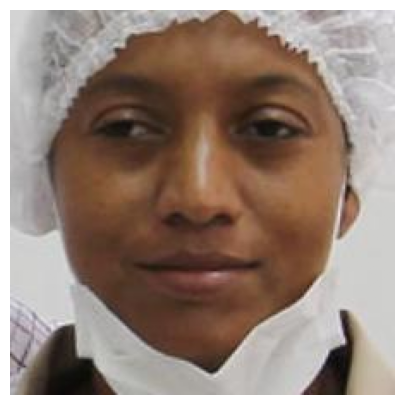

None


In [5]:
ref_image = data['Black'][0]
print(visualize_image(ref_image))

## This is how we load the model

In [6]:
from transformers.models.patchtst.modeling_patchtst import weighted_average


pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16
).to("cuda:0")
#pipe.scheduler = LCMScheduler.from_config(pipe.scheduler.config)

pipe.load_ip_adapter(
    pretrained_model_name_or_path_or_dict="h94/IP-Adapter",
    subfolder="sdxl_models",
    weight_name="ip-adapter_sdxl.bin"
)


Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  3.52it/s]


## This is how we can use it for conditioned generations

conditioning image


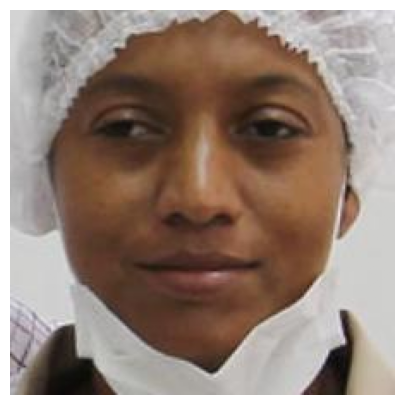

100%|██████████| 50/50 [00:05<00:00,  9.27it/s]


generated image


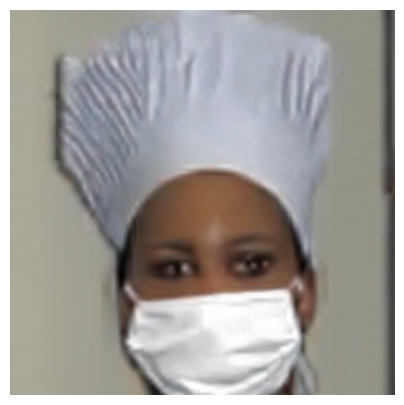

conditioning image


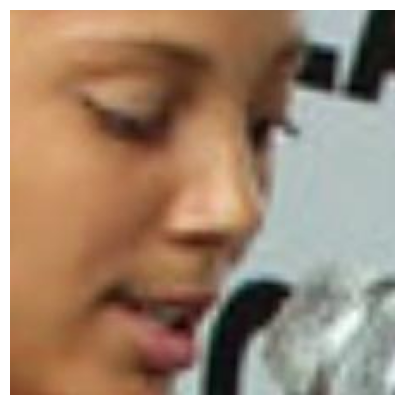

100%|██████████| 50/50 [00:05<00:00,  9.45it/s]


generated image


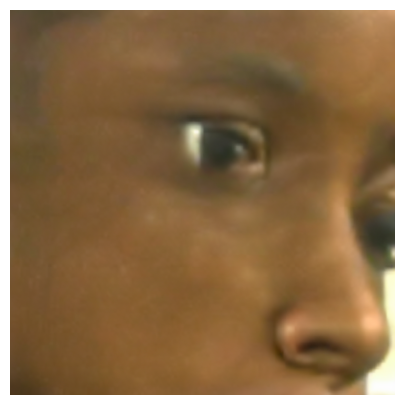

conditioning image


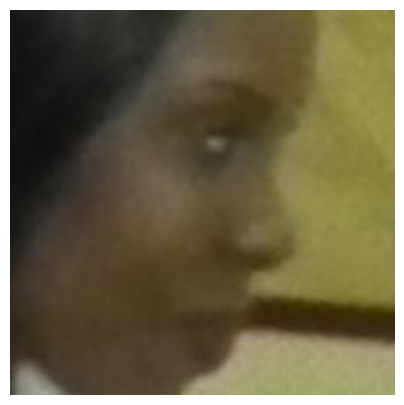

100%|██████████| 50/50 [00:05<00:00,  9.41it/s]


generated image


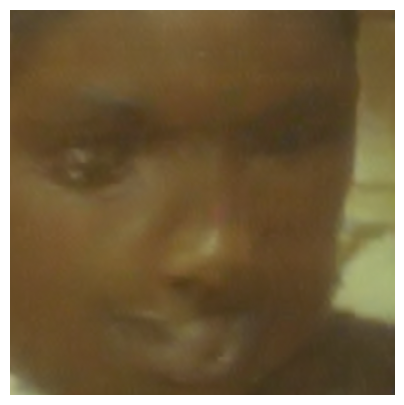

conditioning image


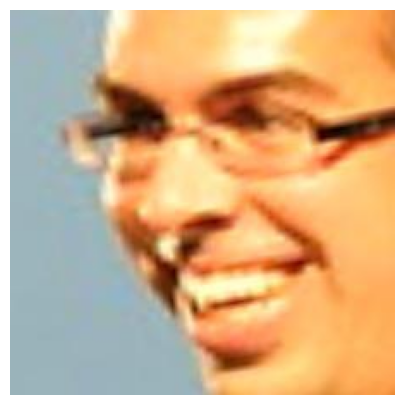

100%|██████████| 50/50 [00:05<00:00,  9.37it/s]


generated image


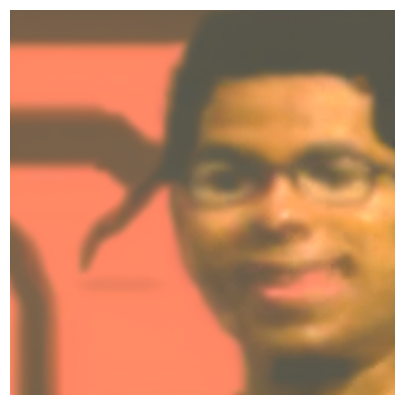

conditioning image


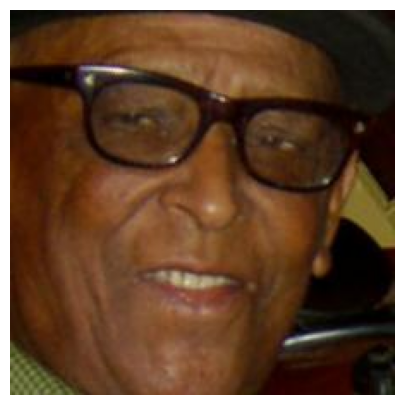

100%|██████████| 50/50 [00:05<00:00,  9.35it/s]


generated image


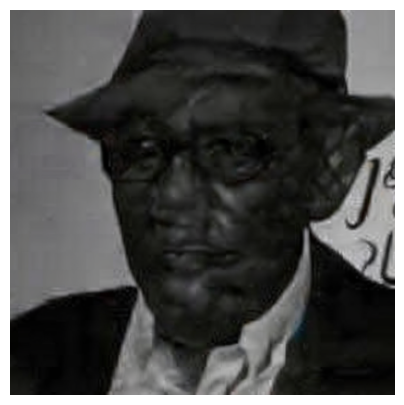

conditioning image


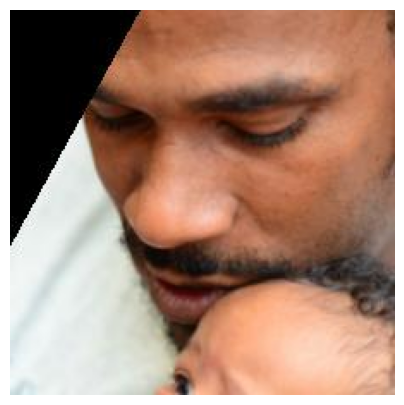

100%|██████████| 50/50 [00:05<00:00,  9.34it/s]


generated image


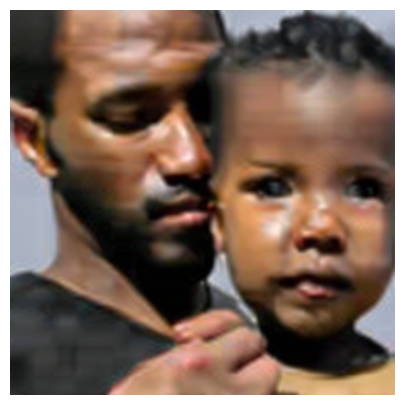

conditioning image


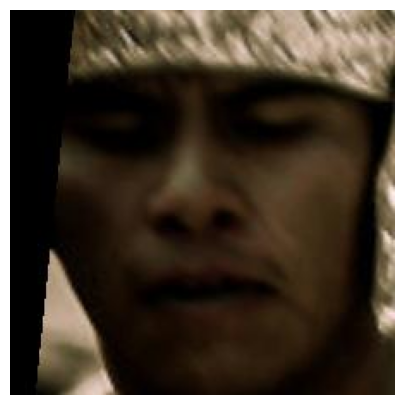

100%|██████████| 50/50 [00:05<00:00,  9.33it/s]


generated image


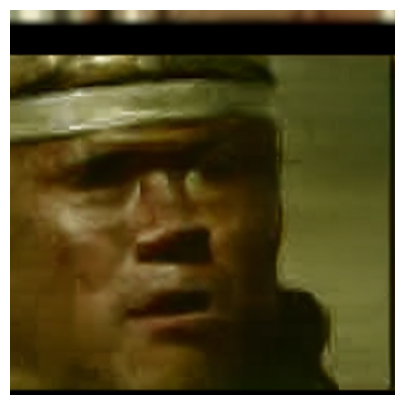

conditioning image


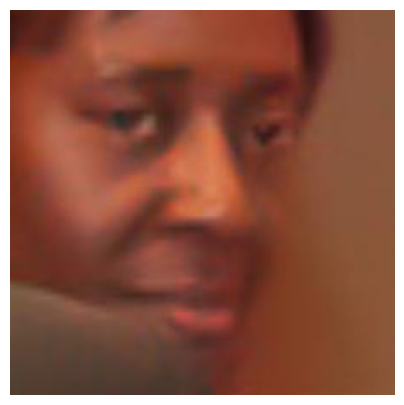

100%|██████████| 50/50 [00:05<00:00,  9.31it/s]


generated image


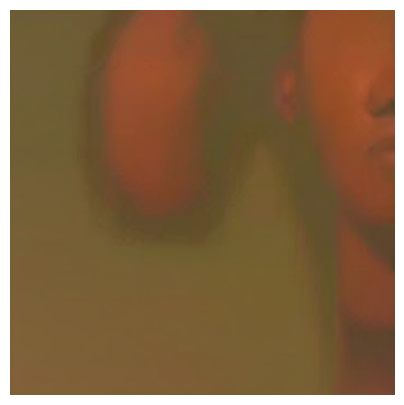

conditioning image


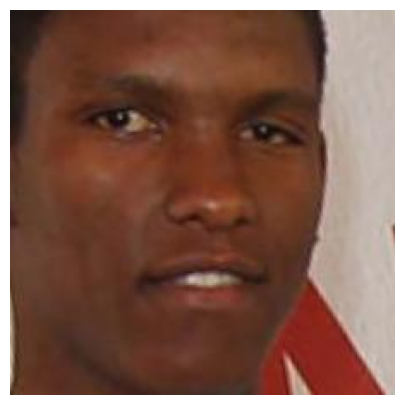

100%|██████████| 50/50 [00:05<00:00,  9.31it/s]


generated image


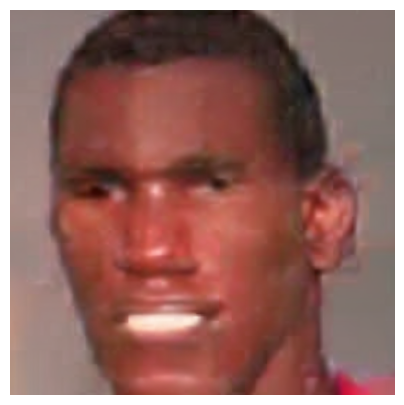

conditioning image


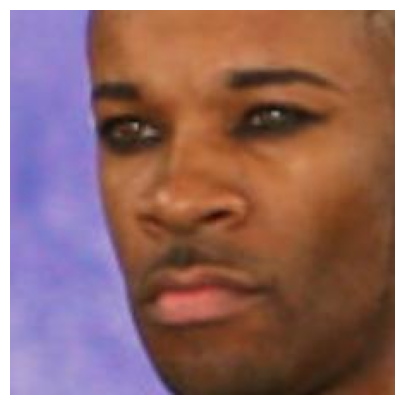

100%|██████████| 50/50 [00:05<00:00,  9.30it/s]


generated image


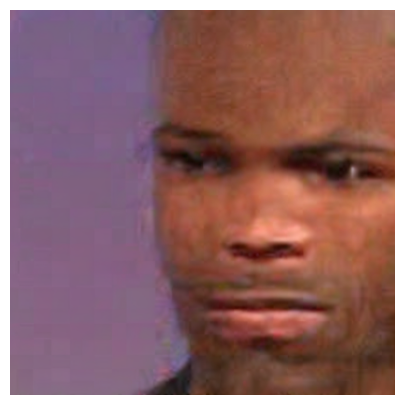

In [7]:
sample_size = 10
for i in range(sample_size):
    pipe.set_ip_adapter_scale(0.8)
    print("conditioning image")
    visualize_image(data['Black'][i])
    #low guidance scale means it should be simialr to the conditioning image
    out_image = pipe(prompt="A black person", ip_adapter_image=data['Black'][i])
    print("generated image")
    visualize_image(out_image.images[0])

In [ ]:
import torch
import torch.nn.functional as F

#Helper functions
def concate_activations(activations):
    pass
def reshape_activations(activations):
    pass

@torch.inference_mode()
def cache_activations(
    pipe,
    data_by_class,                 # {class_name: [PIL or np.ndarray, ...]}
    prompts_by_class=None,         # {class_name: "prompt ..."} (optional)
    layer_path="unet.mid_block",   # e.g. "unet.down_blocks.2.resnets.1"
    batch_size=16,                   # Reduced default batch size to minimize memory
    ip_adapter_scale=0.8,
    clear_cache=True,               # Clear GPU cache between batches
):
    """
    Cache activations from a diffusion model layer.
    
    Memory-optimized version that:
    - Processes smaller batches (default batch_size=1)
    - Moves activations to CPU immediately
    - Clears GPU cache between batches
    - Converts to numpy incrementally
    """
    # resolve target module
    def _get_module(root, dotted):
        m = root
        for p in dotted.split('.'):
            m = getattr(m, p) if not p.isdigit() else m[int(p)]
        return m

    mod = _get_module(pipe, layer_path)
    captured = []
    hook = mod.register_forward_hook(lambda _, __, out: captured.append(out.detach()))
    pipe.set_ip_adapter_scale(ip_adapter_scale)

    activations = {k: [] for k in data_by_class}

    for cls, imgs in data_by_class.items():
        prm = (prompts_by_class.get(cls, "") if prompts_by_class else "")
        # ensure PIL
        def _to_pil(x): 
            return x if isinstance(x, Image.Image) else Image.fromarray(x)
        imgs = [ _to_pil(x) for x in imgs ]

        for i in range(0, len(imgs), batch_size):
            batch = imgs[i:i+batch_size]
            prompts = [prm] * len(batch)

            captured.clear()
            
            # Generate and capture activations
            # NOTE: wrap batch per number of adapters (1 adapter -> [batch])
            # Use output_type="latent" to skip VAE decode and save memory (we only need UNet activations)
            _ = pipe(
                prompt=prompts, 
                ip_adapter_image=[batch],
                output_type="latent"  # Skip VAE decode to save memory
            )

            A = captured[-1]                # (B, C, H, W) or (B, D)
            print(f"Batch {i//batch_size + 1}: Captured activations shape {A.shape}")
            
            # Flatten all dimensions except batch (concatenate channel, height, width)
            A = A.flatten(1) if A.dim() > 1 else A
            
            # Move to CPU and convert to numpy immediately to free GPU memory
            A_cpu = A.float().cpu()
            A_numpy = A_cpu.numpy()
            
            # Store numpy array (much smaller memory footprint)
            activations[cls].append(A_numpy)
            
            # Clear GPU cache if requested
            if clear_cache:
                del A, A_cpu
                torch.cuda.empty_cache()

    hook.remove()
    
    # Concatenate all batches for each class
    result = {}
    for cls, v in activations.items():
        if v:
            result[cls] = np.concatenate(v, axis=0)
        else:
            result[cls] = np.empty(0)
    
    return result

## Let's try to parallelize the activation caching
def _worker_cache_activations(
    gpu_id,
    classes_to_process,
    data_by_class,
    prompts_by_class,
    model_name,
    layer_path,
    batch_size,
    guidance_scale,
    ip_adapter_scale,
    clear_cache,
):
    """
    Worker function for parallel processing on a specific GPU.
    Loads pipeline on the assigned GPU and processes assigned classes.
    """
    device = f"cuda:{gpu_id}"
    
    # Load pipeline on this GPU
    print(f"[GPU {gpu_id}] Loading pipeline...")
    pipe = AutoPipelineForText2Image.from_pretrained(
        model_name, torch_dtype=torch.float16
    ).to(device)
    
    pipe.load_ip_adapter(
        pretrained_model_name_or_path_or_dict="h94/IP-Adapter",
        subfolder="sdxl_models",
        weight_name="ip-adapter_sdxl.bin"
    )
    
    # Process only assigned classes
    data_subset = {cls: data_by_class[cls] for cls in classes_to_process}
    prompts_subset = {cls: prompts_by_class.get(cls, "") for cls in classes_to_process} if prompts_by_class else None
    
    print(f"[GPU {gpu_id}] Processing classes: {classes_to_process}")
    result = cache_activations(
        pipe=pipe,
        data_by_class=data_subset,
        prompts_by_class=prompts_subset,
        layer_path=layer_path,
        batch_size=batch_size,
        guidance_scale=guidance_scale,
        ip_adapter_scale=ip_adapter_scale,
        clear_cache=clear_cache,
    )
    
    # Clean up
    del pipe
    torch.cuda.empty_cache()
    
    return result


def cache_activations_parallel(
    data_by_class,                 # {class_name: [PIL or np.ndarray, ...]}
    prompts_by_class=None,         # {class_name: "prompt ..."} (optional)
    gpu_ids=None,                  # List of GPU IDs to use (e.g., [0, 1, 2]). If None, auto-detect
    model_name="stabilityai/stable-diffusion-xl-base-1.0",
    layer_path="unet.mid_block",
    batch_size=1,
    guidance_scale=5.5,
    ip_adapter_scale=0.8,
    clear_cache=True,
):
    """
    Parallelized version of cache_activations that distributes classes across multiple GPUs.
    
    Parameters:
    - data_by_class: Dictionary mapping class names to lists of images
    - prompts_by_class: Optional dictionary mapping class names to prompts
    - gpu_ids: List of GPU device IDs to use (e.g., [0, 1, 2]). If None, uses all available GPUs
    - model_name: Model name/path for the pipeline
    - layer_path: Layer path to hook
    - batch_size: Batch size per GPU
    - guidance_scale: Guidance scale
    - ip_adapter_scale: IP adapter scale
    - clear_cache: Whether to clear GPU cache between batches
    
    Returns:
    - Dictionary mapping class names to numpy arrays of activations
    """
    from multiprocessing import Process, Queue
    import time
    
    # Auto-detect GPUs if not specified
    if gpu_ids is None:
        gpu_ids = list(range(torch.cuda.device_count()))
    
    if len(gpu_ids) == 0:
        raise ValueError("No GPUs available!")
    
    classes = list(data_by_class.keys())
    num_classes = len(classes)
    num_gpus = len(gpu_ids)
    
    # Distribute classes across GPUs
    classes_per_gpu = num_classes // num_gpus
    remainder = num_classes % num_gpus
    
    class_assignments = []
    start_idx = 0
    for i, gpu_id in enumerate(gpu_ids):
        # Distribute remainder classes to first few GPUs
        num_classes_this_gpu = classes_per_gpu + (1 if i < remainder else 0)
        end_idx = start_idx + num_classes_this_gpu
        class_assignments.append((gpu_id, classes[start_idx:end_idx]))
        start_idx = end_idx
    
    print(f"Distributing {num_classes} classes across {num_gpus} GPU(s):")
    for gpu_id, classes_list in class_assignments:
        print(f"  GPU {gpu_id}: {len(classes_list)} classes - {classes_list}")
    
    # Process in parallel using multiprocessing
    processes = []
    result_queue = Queue()
    
    def worker_wrapper(args):
        """Wrapper to put results in queue"""
        gpu_id, classes_list = args
        try:
            result = _worker_cache_activations(
                gpu_id=gpu_id,
                classes_to_process=classes_list,
                data_by_class=data_by_class,
                prompts_by_class=prompts_by_class,
                model_name=model_name,
                layer_path=layer_path,
                batch_size=batch_size,
                guidance_scale=guidance_scale,
                ip_adapter_scale=ip_adapter_scale,
                clear_cache=clear_cache,
            )
            result_queue.put((gpu_id, result))
        except Exception as e:
            result_queue.put((gpu_id, f"ERROR: {str(e)}"))
    
    # Start all processes
    start_time = time.time()
    for gpu_id, classes_list in class_assignments:
        p = Process(target=worker_wrapper, args=((gpu_id, classes_list),))
        p.start()
        processes.append(p)
    
    # Collect results
    all_results = {}
    for _ in range(num_gpus):
        gpu_id, result = result_queue.get()
        if isinstance(result, str) and result.startswith("ERROR"):
            raise RuntimeError(f"Error on GPU {gpu_id}: {result}")
        all_results.update(result)
    
    # Wait for all processes to finish
    for p in processes:
        p.join()
    
    elapsed_time = time.time() - start_time
    print(f"\n✓ Completed in {elapsed_time:.1f} seconds ({elapsed_time/60:.1f} minutes)")
    
    return all_results

# These are helper functions for the steering

def create_steering_hook(
    classifier,                    # K_Steering classifier instance
    target_classes=None,           # List of class names to steer towards
    avoid_classes=None,            # List of class names to steer away from
    alpha=0.1,                     # Step size for gradient-based modification
):
    """
    Creates a forward hook that modifies activations in-place using classifier gradients.
    
    The hook:
    1. Flattens activations to match classifier input
    2. Computes classifier logits
    3. Creates loss: sum(target_logits) - sum(avoid_logits)
    4. Computes gradients w.r.t. activations
    5. Modifies activations using gradients
    
    Parameters:
    - classifier: K_Steering classifier instance (must be trained)
    - target_classes: List of class names to steer towards (e.g., ["Black"])
    - avoid_classes: List of class names to steer away from (e.g., ["White"])
    - alpha: Step size for gradient update
    - layer_path: Layer path (for reference/documentation)
    
    Returns:
    - hook_function: A function that can be registered as a forward hook
    """
    
    # Get class indices
    target_indices = []
    avoid_indices = []
    
    if target_classes:
        target_indices = [classifier.class_names.index(cls) for cls in target_classes 
                         if cls in classifier.class_names]
    
    if avoid_classes:
        avoid_indices = [classifier.class_names.index(cls) for cls in avoid_classes 
                        if cls in classifier.class_names]
    
    if not target_indices and not avoid_indices:
        # No steering needed, return identity hook
        def identity_hook(module, input, output):
            return output
        return identity_hook
    
    def steering_hook(module, input, output):
        """
        Forward hook that modifies activations based on classifier gradients.
        """
        # Store original shape
        original_shape = output.shape
        
        # Flatten activations (preserve batch dimension)
        A_flat = output.flatten(1) if output.dim() > 1 else output  # [B, features]
        
        # Enable gradients (even if pipeline is in inference mode)
        with torch.enable_grad():
            # Detach and require gradients for the flattened tensor
            A_flat = A_flat.detach().requires_grad_(True)
            
            # Forward pass through classifier
            classifier.classifier.eval()
            logits = classifier.classifier(A_flat)  # [B, num_classes]
            
            # Compute loss: maximize target logits, minimize avoid logits
            loss = 0.0
            
            if target_indices:
                # Sum of logits for target classes (we want to maximize, so negative in loss)
                target_logits = logits[:, target_indices]  # [B, len(target_indices)]
                loss = loss - target_logits.sum()  # Negative because we maximize via gradient ascent
            
            if avoid_indices:
                # Sum of logits for avoid classes (we want to minimize, so positive in loss)
                avoid_logits = logits[:, avoid_indices]  # [B, len(avoid_indices)]
                loss = loss + avoid_logits.sum()  # Positive because we minimize via gradient descent
            
            # Compute gradients
            loss.backward()
            
            # Get gradients w.r.t. flattened activations
            grad_flat = A_flat.grad  # [B, features]
        
        # Reshape gradients to match original output shape
        grad = grad_flat.view(original_shape)
        
        # Modify output in-place using gradients
        # For target: we want to maximize, so add gradient (gradient ascent)
        # For avoid: we want to minimize, so subtract gradient (gradient descent)
        # The loss already has the right signs, so we just add alpha * grad
        modified_output = output + alpha * grad
        
        # Detach to stop gradient flow
        return modified_output.detach()
    
    return steering_hook


def apply_steering_hook(
    pipe,
    classifier,                    # K_Steering classifier instance
    target_classes=None,           # List of class names to steer towards
    avoid_classes=None,            # List of class names to steer away from
    alpha=0.1,                     # Step size for gradient-based modification
    layer_path="unet.mid_block",   # Layer path to hook
):
    """
    Applies a steering hook to the pipeline and returns the hook handle.
    
    Parameters:
    - pipe: The diffusion pipeline
    - classifier: K_Steering classifier instance
    - target_classes: List of class names to steer towards
    - avoid_classes: List of class names to steer away from
    - alpha: Step size for gradient update
    - layer_path: Layer path to hook (e.g., "unet.mid_block")
    
    Returns:
    - hook_handle: Handle to remove the hook later
    """
    
    # Helper to get module
    def _get_module(root, dotted):
        m = root
        for p in dotted.split('.'):
            m = getattr(m, p) if not p.isdigit() else m[int(p)]
        return m
    
    mod = _get_module(pipe, layer_path)
    
    # Create and register hook
    hook_fn = create_steering_hook(
        classifier=classifier,
        target_classes=target_classes,
        avoid_classes=avoid_classes,
        alpha=alpha,
    )
    
    hook_handle = mod.register_forward_hook(hook_fn)
    
    return hook_handle



## Let's get activations

In [9]:
data.keys()

dict_keys(['Black', 'East_Asian', 'Indian', 'Latino_Hispanic', 'Middle_Eastern', 'Southeast_Asian', 'White'])

In [ ]:
acts ={race:[] for race in data.keys()}
for race in data.keys():
    print(f"generating activations for {race} ")
    data_by_class = {race: data[race]}
    prompts_by_class = {race: f"A {race} person"}
    acts[race] = cache_activations(
        pipe,
        data_by_class=data_by_class,
        prompts_by_class=prompts_by_class,
        layer_path="unet.mid_block",   # change to any valid UNet submodule
        batch_size=8,
        ip_adapter_scale=0.8,
        clear_cache=True,                # Clear GPU cache between batches
    )

generating activations for Black 


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:38<00:00,  1.30it/s]


Batch 1: Captured activations shape torch.Size([16, 1280, 32, 32])


100%|██████████| 50/50 [00:38<00:00,  1.30it/s]


...

100%|██████████| 50/50 [00:38<00:00,  1.30it/s]


Batch 10: Captured activations shape torch.Size([16, 1280, 32, 32])


100%|██████████| 50/50 [00:38<00:00,  1.30it/s]


Batch 11: Captured activations shape torch.Size([16, 1280, 32, 32])


 80%|████████  | 40/50 [00:30<00:07,  1.29it/s]

## Parallelized Activation Caching (Multi-GPU)


In [ ]:
# Parallelized version - processes all classes across multiple GPUs simultaneously
# This is much faster than processing sequentially!

# Prepare data for all classes
data_by_class = data  # All classes
prompts_by_class = {race: f"A {race} person" for race in data.keys()}

# Use parallelized caching
# Option 1: Auto-detect and use all available GPUs
acts_parallel = cache_activations_parallel(
    data_by_class=data_by_class,
    prompts_by_class=prompts_by_class,
    gpu_ids=None,  # None = use all available GPUs, or specify [0, 1, 2] for specific GPUs
    layer_path="unet.mid_block",
    batch_size=1,  # Batch size per GPU
    guidance_scale=5.5,
    ip_adapter_scale=0.8,
    clear_cache=True,
)

# Option 2: Specify which GPUs to use
# acts_parallel = cache_activations_parallel(
#     data_by_class=data_by_class,
#     prompts_by_class=prompts_by_class,
#     gpu_ids=[0, 1, 2],  # Use GPUs 0, 1, and 2
#     layer_path="unet.mid_block",
#     batch_size=1,
#     guidance_scale=5.5,
#     ip_adapter_scale=0.8,
#     clear_cache=True,
# )

print(f"\n✓ Collected activations for {len(acts_parallel)} classes")
for cls, activations in acts_parallel.items():
    print(f"  {cls}: shape {activations.shape}")


In [ ]:
print(acts.keys())

dict_keys(['White'])


In [ ]:
input_dim = acts['Black'].shape[-1]
num_classes = len(acts)

print(f"Input dimension: {input_dim}")
print(f"Number of classes: {num_classes}")
print(f"Classes: {list(acts.keys())}")

# Initialize and train the classifier
classifier = K_Steering(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_dim=256,
    lr=1e-3,
    device='cuda'
)

# Train on the cached activations
classifier.fit(
    activations_dict=acts,
    epochs=100,
    batch_size=4
)

print("\nClassifier trained! You can now use it for debiasing.")

KeyError: 'Black'

In [ ]:
# Example: Compare images with and without steering

conditioning_image = data['Black'][0]
prompt = "A black person"
pipe.set_ip_adapter_scale(0.8)

# Generate WITHOUT steering (baseline)
print("Generating baseline image (no steering)...")
baseline_result = pipe(
    prompt=prompt,
    ip_adapter_image=conditioning_image,
    guidance_scale=5.5
)
visualize_image(baseline_result.images[0], title="Baseline (No Steering)")

# Generate WITH steering
print("Generating image with steering hook...")
hook_handle = apply_steering_hook(
    pipe=pipe,
    classifier=classifier.classifier,
    target_classes=[],
    avoid_classes=["Black"],
    alpha=0.1,
    layer_path="unet.mid_block"
)

steered_result = pipe(
    prompt=prompt,
    ip_adapter_image=conditioning_image,
    guidance_scale=5.5
)
visualize_image(steered_result.images[0], title="Steered (Towards Black, Away from White)")

# Clean up
hook_handle.remove()
print("Comparison complete!")